In [65]:
from sklearn.datasets import fetch_kddcup99
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
dataset = fetch_kddcup99(subset=None)
N = dataset.data.shape[0]
D = dataset.data.shape[1]

In [48]:
def ToInt(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal


In [49]:
df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
print(df_normal)

C:\Users\jonsn\AppData\Local\Temp\ipykernel_5232\3011900221.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


        0   1   2   3    4     5   6   7   8   9   ...  31   32     33   34  \
0        0   1  22   9  164  4773   0   0   0   0  ...   9    9  100.0  0.0   
1        0   1  22   9  222   465   0   0   0   0  ...  19   19  100.0  0.0   
2        0   1  22   9  218  1316   0   0   0   0  ...  29   29  100.0  0.0   
3        0   1  22   9  202  1316   0   0   0   0  ...  39   39  100.0  0.0   
4        0   1  22   9  200  2006   0   0   0   0  ...  49   49  100.0  0.0   
...     ..  ..  ..  ..  ...   ...  ..  ..  ..  ..  ...  ..  ...    ...  ...   
494016   0   1  22   9  293  1856   0   0   0   0  ...  86  255  100.0  0.0   
494017   0   1  22   9  265  2254   0   0   0   0  ...   6  255  100.0  0.0   
494018   0   1  22   9  186  1179   0   0   0   0  ...  16  255  100.0  0.0   
494019   0   1  22   9  274  1179   0   0   0   0  ...  26  255  100.0  0.0   
494020   0   1  22   9  202  1213   0   0   0   0  ...   6  255  100.0  0.0   

           35   36   37    38   39   40  
0        

In [ ]:
def cost(D, C):
    cost = 0
    for i in range(D.shape[0]):
        dist = np.linalg.norm(D[i] - C, axis=1)
        cost += min(dist)**2
    return cost

In [51]:
DATA = df_normal.to_numpy()
DATA.shape

(494021, 41)

In [ ]:
costs = []

for X in [5, 10, 15, 20, 25]:
    costs.extend([[]])
    for i in range(5):
        M = np.random.normal(0, 1/np.sqrt(X), size=(D, X))
        E = DATA @ M
        
        kE = KMeans(n_clusters=15)
        kE.fit(E)
        A = kE.cluster_centers_
        
        kDATA = KMeans(n_clusters=15)
        kDATA.fit(DATA)
        B = kDATA.cluster_centers_
        
        CostA = cost(DATA, A @ np.linalg.pinv(M))
        CostB = cost(DATA, B)
        costs[-1].append((CostA, CostB))

for i in range(len(costs)):
    for j in range(5):
        print(f'x = {(i+1)*5} Cost(A) : {costs[i][j][0]} Cost(B) : {costs[i][j][1]}')

x = 1 Cost(A) : 1329003009117.3228 Cost(B) : 18193927694.34848
x = 1 Cost(A) : 1296610335555.1729 Cost(B) : 16593402708.067142
x = 1 Cost(A) : 1274423943703.6294 Cost(B) : 16656207237.240633
x = 1 Cost(A) : 1240075787243.172 Cost(B) : 16656109610.908903
x = 1 Cost(A) : 1296806811136.2717 Cost(B) : 16712968871.69109
x = 2 Cost(A) : 1223451798637.599 Cost(B) : 17112427980.77979
x = 2 Cost(A) : 960959454103.2577 Cost(B) : 16723318274.929787
x = 2 Cost(A) : 1268511131842.3042 Cost(B) : 16650045494.151705
x = 2 Cost(A) : 1134109304504.7273 Cost(B) : 19702055663.02932
x = 2 Cost(A) : 1022828559788.8063 Cost(B) : 19223371951.90654
x = 3 Cost(A) : 1128460923751.5593 Cost(B) : 19310457220.577557
x = 3 Cost(A) : 842038905783.869 Cost(B) : 17274792568.39173
x = 3 Cost(A) : 1097993929961.4696 Cost(B) : 16727929133.345737
x = 3 Cost(A) : 774013891482.4282 Cost(B) : 17905065328.006336
x = 3 Cost(A) : 1039557681882.3463 Cost(B) : 17094066497.96791
x = 4 Cost(A) : 683484603266.6499 Cost(B) : 165930019

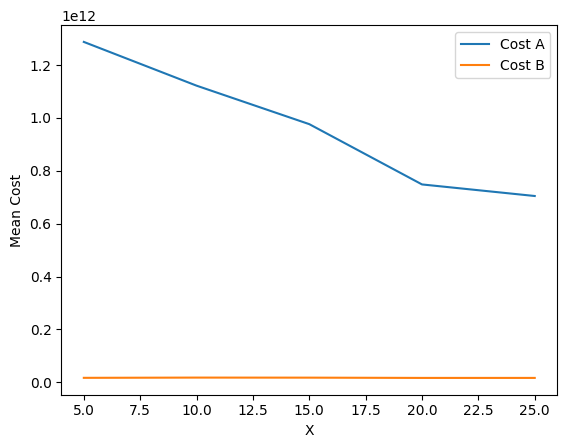

In [67]:
# plot the costs as a function of X
mean_costs_A = [np.mean([c[0] for c in cost_list]) for cost_list in costs]
mean_costs_B = [np.mean([c[1] for c in cost_list]) for cost_list in costs]
plt.plot([5, 10, 15, 20, 25], mean_costs_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], mean_costs_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.show()

In [68]:
# b)